# EDA and Preprocessing
This notebook explores the raw ECG and PCG signals to determine the necessary preprocessing steps before training our models.

This time, each patient has 4 channels: APEX, LLSB, LUSB, and RUSB. We will put them together as one input, with the full 30 seconds for each channel.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
from IPython.display import Audio, display

# Importing preprocessing functions from src
PROJECT_DIR = os.path.abspath('..') if os.path.isdir('../src') else os.path.abspath('.')
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)
from src.preprocessing import (
    preprocess_signals, segment_signals, load_raw_metadata,
    build_patient_metadata, load_patient_signals, preprocess_dataset,
    CHANNEL_ORDER, CHANNEL_ORDER_STRING, ECG_FS, PCG_FS, ECG_SAMPLES, PCG_SAMPLES,
)
from src.data_loader import ProcessedCardioDataset

# Importing data

# Set paths
RAW_DIR = os.path.join(PROJECT_DIR, 'data/raw')
DATA_DIR = os.path.join(RAW_DIR, 'HFrEF_5_folds')

# read all 5 fold label files, and the separate test labels
# the function also calculates HFrEF labels: LVEF <= 0.4 is Label 1
records_df, test_records_df = load_raw_metadata(RAW_DIR)

print(records_df.head()) # preview

   Patient_ID        Record_ID Channel  LVEF  Label  Fold  \
0  1005263204  1005263204_APEX    APEX  0.72      0     0   
1  1005263204  1005263204_LLSB    LLSB  0.72      0     0   
2  1005263204  1005263204_LUSB    LUSB  0.72      0     0   
3  1005263204  1005263204_RUSB    RUSB  0.72      0     0   
4  1007048209  1007048209_APEX    APEX  0.62      0     0   

                                            ECG_Path  \
0  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...   
1  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...   
2  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...   
3  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...   
4  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...   

                                            PCG_Path  
0  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...  
1  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...  
2  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...  
3  e:\Deep Learning\CardioFusion\data\raw\HFrEF_5...  
4  e:\Deep Learning\C

C:\Users\BluRay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Grouping the 4 Channels
The old dataframe had a separate row for every recording. For example,
`1005263204_APEX` and `1005263204_LLSB` belong to the same patient.

We need one row for that patient, with all 4 channels together. The order will
always be **APEX, LLSB, LUSB, RUSB**. If a channel is missing or the labels don't
match, we stop and check it before preprocessing.

In [2]:
# group the recordings by Patient_ID
df = build_patient_metadata(records_df)

print(f"Total recordings: {len(records_df)}")
print(f"Total patients after grouping: {len(df)}")
print(df[['Patient_ID', 'LVEF', 'Label', 'Fold', 'Channel_Order']].head())

Total recordings: 2000
Total patients after grouping: 500
   Patient_ID  LVEF  Label  Fold        Channel_Order
0  1001025030  0.69      0     2  APEX|LLSB|LUSB|RUSB
1  1001066710  0.60      0     3  APEX|LLSB|LUSB|RUSB
2  1001267891  0.46      0     2  APEX|LLSB|LUSB|RUSB
3  1002087069  0.71      0     1  APEX|LLSB|LUSB|RUSB
4  1002189764  0.64      0     2  APEX|LLSB|LUSB|RUSB


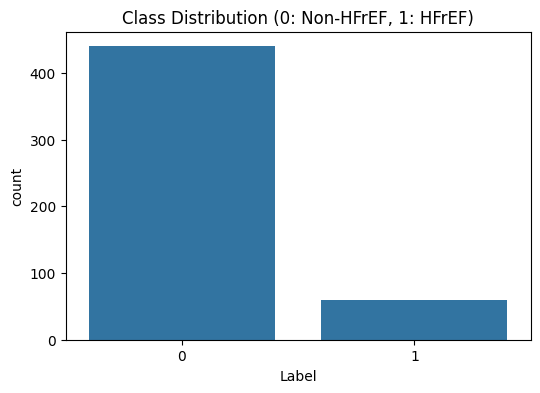

Total Subjects: 500
Non-HFrEF Subjects (Label 0): 440
HFrEF Subjects (Label 1): 60


In [3]:
# Check the exact imbalance (counting patients now)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label')
plt.title('Class Distribution (0: Non-HFrEF, 1: HFrEF)')
plt.show()

print(f"Total Subjects: {len(df)}")
print(f"Non-HFrEF Subjects (Label 0): {len(df[df['Label'] == 0])}")
print(f"HFrEF Subjects (Label 1): {df['Label'].sum()}")

In [4]:
# find the ECG and PCG paths by searching through the fold directories
def get_signal_paths(record_id, base_dir=DATA_DIR):
    # record_id already looks like '1005263204_APEX'
    for i in range(5):
        fold_dir = os.path.join(base_dir, f'fold_{i}')
        ecg_path = os.path.join(fold_dir, f"{record_id}_ECG.wav")
        pcg_path = os.path.join(fold_dir, f"{record_id}_PCG.wav")

        if os.path.exists(ecg_path) and os.path.exists(pcg_path):
            return ecg_path, pcg_path

    raise FileNotFoundError(f"Files for record {record_id} not found.")

# get the first patient from the dataframe to test
sample_patient = df.iloc[0]

# load all 4 channels at their correct sampling rates
ecg_sig, pcg_sig = load_patient_signals(sample_patient)

print(f"ECG shape: {ecg_sig.shape}")  # (4, 15000)
print(f"PCG shape: {pcg_sig.shape}")  # (4, 120000)

ECG shape: (4, 15000)
PCG shape: (4, 120000)


## Preprocessing Steps

### 1. Signal Filtering and Normalization
Raw physiological signals contain noise that confuses neural networks. 
* **Bandpass Filtering:** We use a Butterworth filter to isolate the frequencies that matter. For the ECG, we keep 0.5 to 40 Hz to remove baseline wander (usually caused by breathing). For the PCG, we keep 25 to 400 Hz to isolate the actual heart sounds.
* **Z-score Normalization:** We subtract the mean and divide by the standard deviation. This puts both the ECG and PCG on the same numerical scale (a mean of 0 and a standard deviation of 1). We do this separately for each channel, with a small value in the denominator to avoid dividing by zero.

### 2. Signal Segmentation (Skipped For Now)
Our raw recordings are 30 seconds long. If we use segmentation, we can chop each channel into 5-second chunks based on its sampling rate.
* **ECG (500 Hz):** 5 seconds * 500 samples/second = 2,500 samples per segment.
* **PCG (4000 Hz):** 5 seconds * 4000 samples/second = 20,000 samples per segment.

This step would do two things: it multiplies our total dataset size by 6, and it keeps the input arrays small enough to train efficiently on a standard Kaggle GPU without running out of memory.

For now, we are skipping this step and keeping all 30 seconds. One patient gives us an ECG tensor of `(4, 15000)` and a PCG tensor of `(4, 120000)`.

In [5]:
ecg_clean, pcg_clean = preprocess_signals(ecg_sig, pcg_sig)
# ecg_segments, pcg_segments = segment_signals(ecg_clean, pcg_clean, segment_length_sec=5)

# print(f"Original length: 30 seconds")
# print(f"Created {len(ecg_segments)} synchronized segments of 5 seconds each.")

print(f"Preprocessed ECG shape: {ecg_clean.shape}")
print(f"Preprocessed PCG shape: {pcg_clean.shape}")

Preprocessed ECG shape: (4, 15000)
Preprocessed PCG shape: (4, 120000)


### 3. Extracting and Saving to Disk (PyTorch Tensors)
Instead of processing `.wav` files on the fly during training, the entire dataframe is iterated through once, process all 4 channels for each patient, and save them directly as PyTorch `.pt` tensors.

Saving them as `.pt` files saves a conversion step in the PyTorch `Dataset` class, speeding up data loading during training. Also, a new metadata CSV is generated to map each patient file to its label.

The new files are saved in `patient_4ch/development`. Each patient has one ECG file, one PCG file, and one row in the metadata. The metadata also keeps the fold and channel order.

In [6]:
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data/processed/patient_4ch/development')
os.makedirs(PROCESSED_DIR, exist_ok=True)

processed_records = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing patients"):
    patient_id = row['Patient_ID']
    label = row['Label']

    try:
        # load raw signals for all 4 channels
        ecg_sig, pcg_sig = load_patient_signals(row)

        # preprocess and don't segment
        ecg_clean, pcg_clean = preprocess_signals(ecg_sig, pcg_sig)
        # ecg_segs, pcg_segs = segment_signals(ecg_clean, pcg_clean, segment_length_sec=5)

        # save all 4 channels together as a PyTorch tensor
        ecg_filename = f"{patient_id}_ecg.pt"
        pcg_filename = f"{patient_id}_pcg.pt"

        # convert to float32 tensors and save
        torch.save(torch.tensor(ecg_clean, dtype=torch.float32), os.path.join(PROCESSED_DIR, ecg_filename))
        torch.save(torch.tensor(pcg_clean, dtype=torch.float32), os.path.join(PROCESSED_DIR, pcg_filename))

        processed_record = {
            'Patient_ID': patient_id,
            'LVEF': row['LVEF'],
            'Label': label,
            'Fold': row['Fold'],
            'Channel_Order': CHANNEL_ORDER_STRING,
            'Num_Channels': 4,
            'ECG_File': ecg_filename,
            'PCG_File': pcg_filename,
            'ECG_Samples': ECG_SAMPLES,
            'PCG_Samples': PCG_SAMPLES,
        }
        for channel in CHANNEL_ORDER:
            processed_record[f'{channel}_Record_ID'] = row[f'{channel}_Record_ID']

        processed_records.append(processed_record)
    except Exception as e:
        print(f"Error processing {patient_id}: {e}")
        raise  # fix the problem instead of silently skipping a patient

# save the new metadata mapping after all patients are processed
processed_df = pd.DataFrame(processed_records)
metadata_path = os.path.join(PROCESSED_DIR, 'processed_metadata.csv')
processed_df.to_csv(metadata_path + '.tmp', index=False)
os.replace(metadata_path + '.tmp', metadata_path)
print(f"Finished processing. Saved {len(processed_df)} total patients.")

Processing patients: 100%|██████████| 500/500 [00:20<00:00, 23.96it/s]

Finished processing. Saved 500 total patients.


## Displaying the Signals
The following code displays the raw and preprocessed signals for a selected patient and channel.

Change `RECORD_NUMBER` to choose the patient and `CHANNEL` to choose APEX, LLSB, LUSB, or RUSB. The graphs below show ECG and PCG before and after preprocessing, and the PCG can also be played.

Patient ID: 1007234195
Record ID : 1007234195_APEX
LVEF      : 0.550
Label     : 0 (Non-HFrEF)


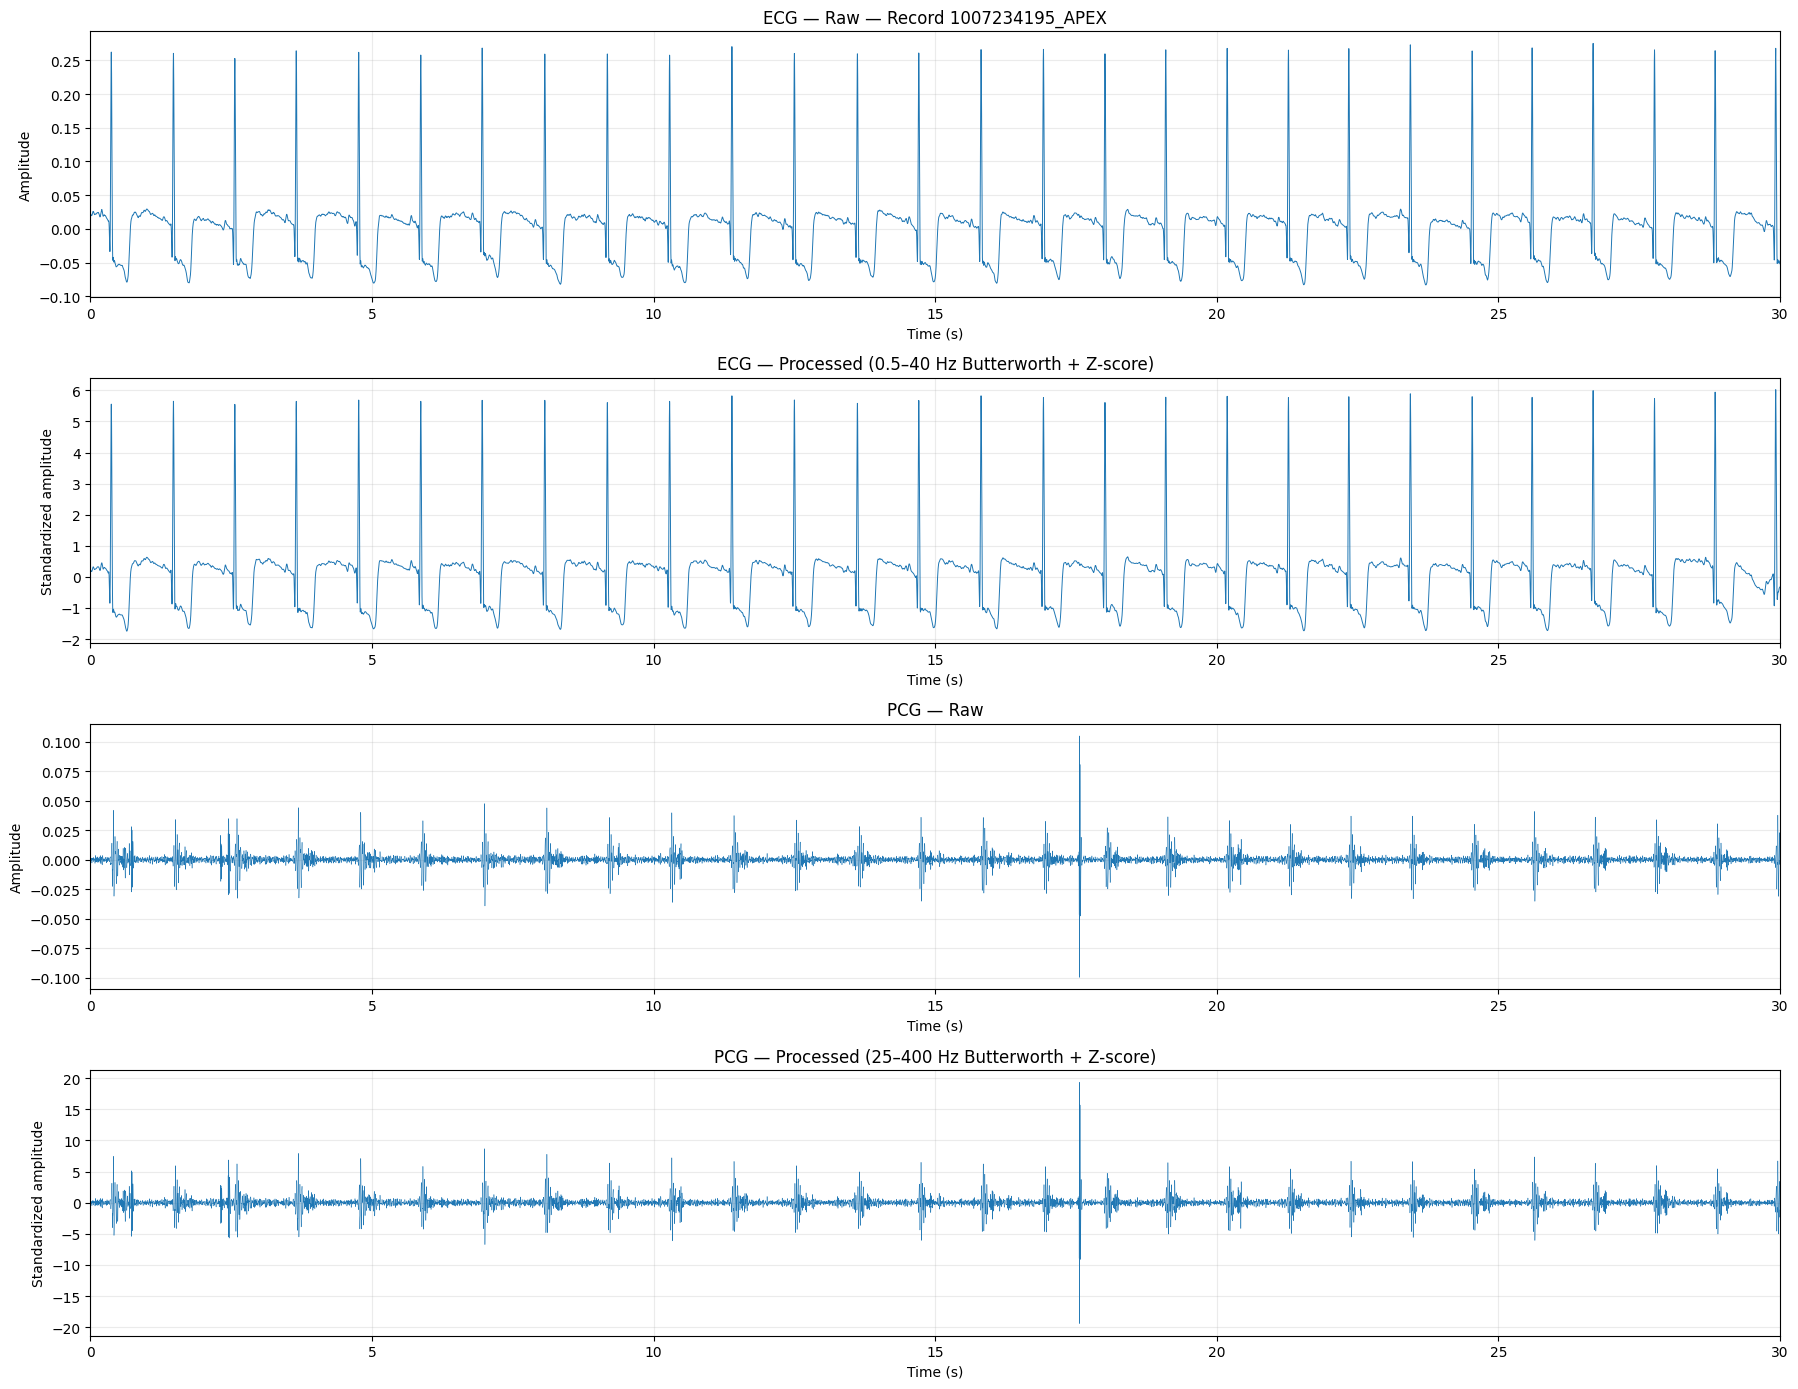

PCG RAW — 30 seconds


PCG PROCESSED — 30 seconds


In [7]:
RECORD_NUMBER = 20  # <----- select the patient number
CHANNEL = 'APEX'   # <----- select APEX, LLSB, LUSB, or RUSB

PATIENT_ID = str(df.loc[RECORD_NUMBER, "Patient_ID"])
RECORD_ID = f"{PATIENT_ID}_{CHANNEL}"
LABEL = int(df.loc[RECORD_NUMBER, "Label"])
LVEF = float(df.loc[RECORD_NUMBER, "LVEF"])

ecg_file, pcg_file = get_signal_paths(RECORD_ID)

# load using the sampling rates defined by the project
ecg_raw_all, pcg_raw_all = load_patient_signals(df.iloc[RECORD_NUMBER])
channel_idx = CHANNEL_ORDER.index(CHANNEL)
ecg_raw = ecg_raw_all[channel_idx]
pcg_raw = pcg_raw_all[channel_idx]

ECG_FS = 500
PCG_FS = 4000
DISPLAY_SECONDS = 30

print(f"Patient ID: {PATIENT_ID}")
print(f"Record ID : {RECORD_ID}")
print(f"LVEF      : {LVEF:.3f}")
print(f"Label     : {LABEL} ({'HFrEF' if LABEL == 1 else 'Non-HFrEF'})")

ecg_processed, pcg_processed = preprocess_signals(ecg_raw, pcg_raw)

# Extract exactly 30 seconds for display/audio
ECG_SAMPLES_30 = ECG_FS * DISPLAY_SECONDS
PCG_SAMPLES_30 = PCG_FS * DISPLAY_SECONDS

ecg_raw_30 = ecg_raw[:ECG_SAMPLES_30]
ecg_processed_30 = ecg_processed[:ECG_SAMPLES_30]

pcg_raw_30 = pcg_raw[:PCG_SAMPLES_30]
pcg_processed_30 = pcg_processed[:PCG_SAMPLES_30]

# Time axes
t_ecg = np.arange(len(ecg_raw_30)) / ECG_FS
t_pcg = np.arange(len(pcg_raw_30)) / PCG_FS

fig, axes = plt.subplots(4, 1, figsize=(18, 14))

# ECG RAW 
axes[0].plot(t_ecg, ecg_raw_30, linewidth=0.7)
axes[0].set_title(f"ECG — Raw — Record {RECORD_ID}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, DISPLAY_SECONDS)
axes[0].grid(True, alpha=0.25)

# ECG PROCESSED 
axes[1].plot(t_ecg, ecg_processed_30, linewidth=0.7)
axes[1].set_title("ECG — Processed (0.5–40 Hz Butterworth + Z-score)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Standardized amplitude")
axes[1].set_xlim(0, DISPLAY_SECONDS)
axes[1].grid(True, alpha=0.25)

# PCG RAW
axes[2].plot(t_pcg, pcg_raw_30, linewidth=0.35)
axes[2].set_title("PCG — Raw")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlim(0, DISPLAY_SECONDS)
axes[2].grid(True, alpha=0.25)

# PCG PROCESSED 
axes[3].plot(t_pcg, pcg_processed_30, linewidth=0.35)
axes[3].set_title("PCG — Processed (25–400 Hz Butterworth + Z-score)")
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Standardized amplitude")
axes[3].set_xlim(0, DISPLAY_SECONDS)
axes[3].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f"PCG RAW — {DISPLAY_SECONDS} seconds")
display(
    Audio(
        data=pcg_raw_30,
        rate=PCG_FS,
        normalize=True
    )
)

print(f"PCG PROCESSED — {DISPLAY_SECONDS} seconds")
display(
    Audio(
        data=pcg_processed_30,
        rate=PCG_FS,
        normalize=True
    )
)

### Displaying All 4 ECG Channels
This shows the 4 ECG channels for the same patient together, before and after
preprocessing. These are the channels that go into the model as one input.
The recordings from different sites are not necessarily aligned in time.

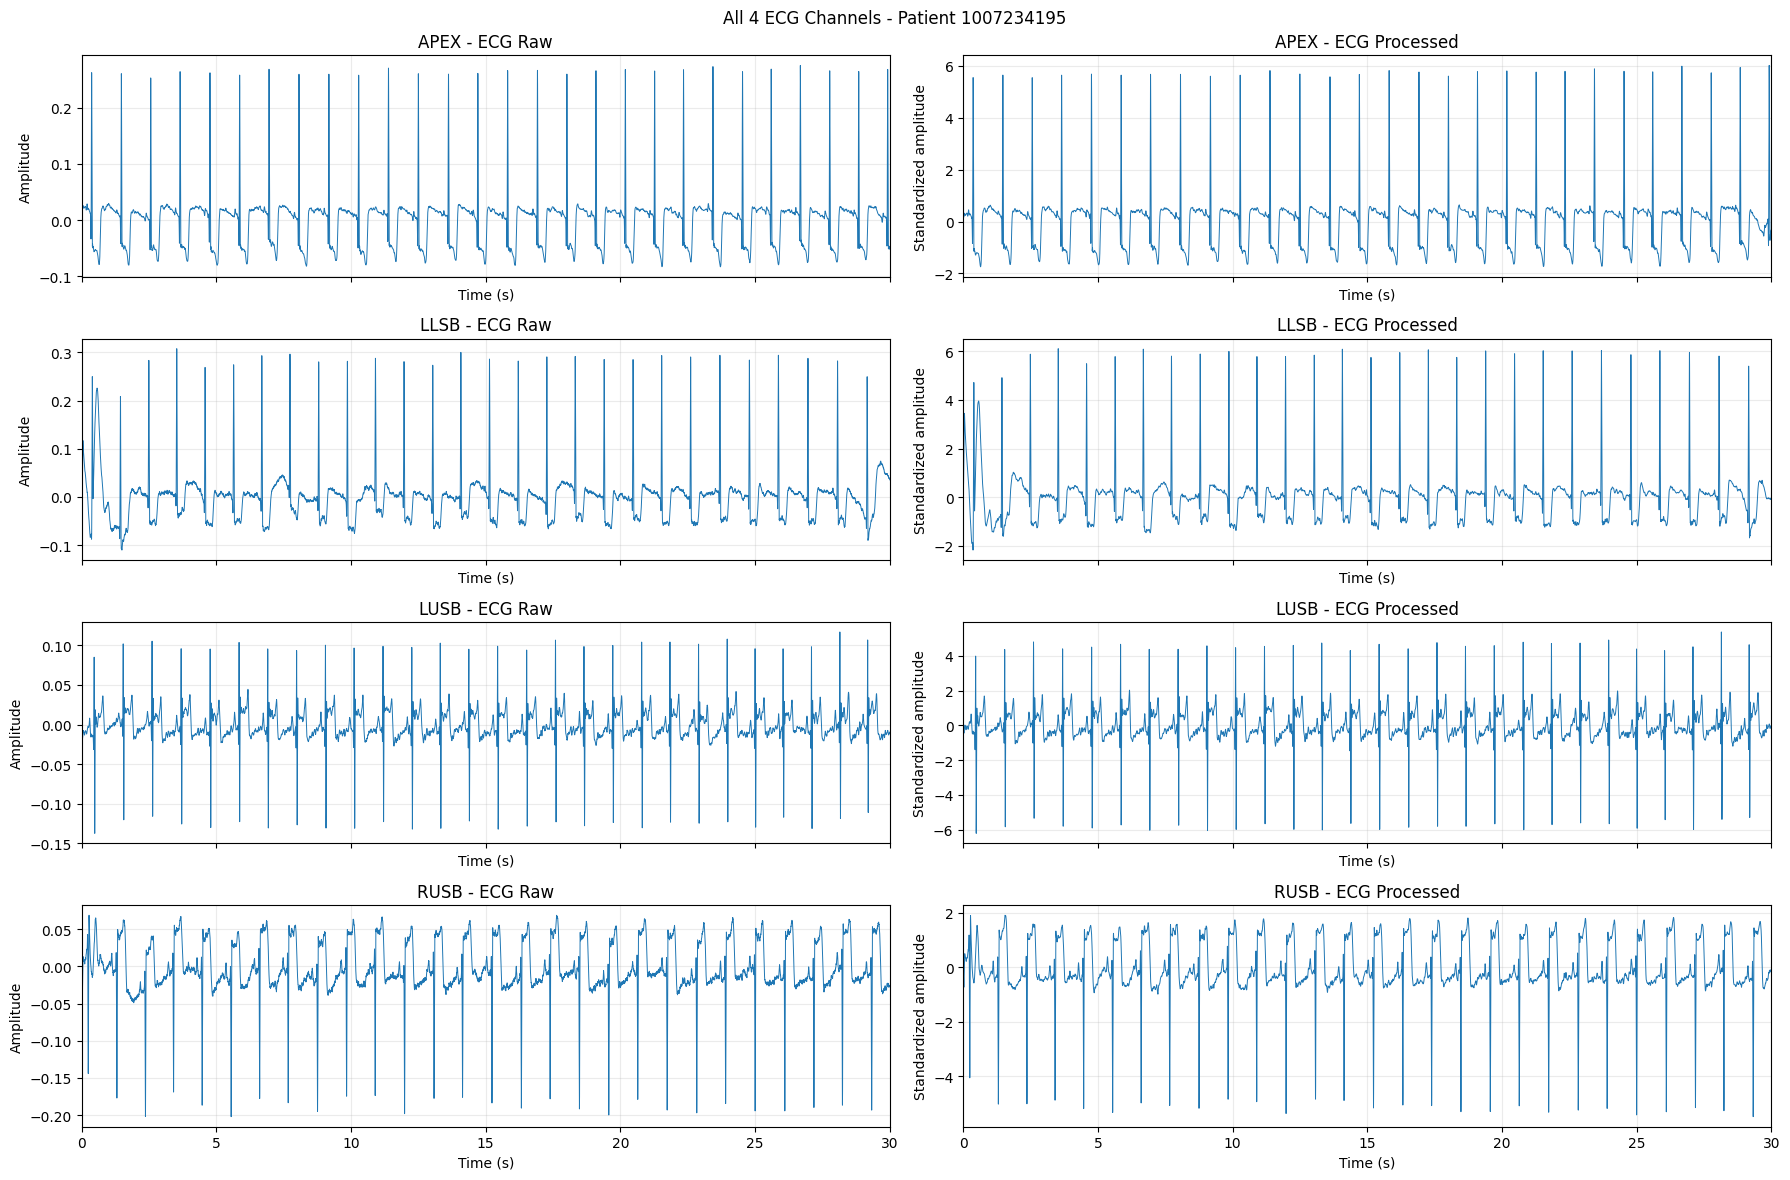

In [8]:
ecg_processed_all, pcg_processed_all = preprocess_signals(ecg_raw_all, pcg_raw_all)

fig, axes = plt.subplots(4, 2, figsize=(18, 12), sharex=True)

for channel_idx, channel in enumerate(CHANNEL_ORDER):
    # ECG RAW
    axes[channel_idx, 0].plot(t_ecg, ecg_raw_all[channel_idx, :ECG_SAMPLES_30], linewidth=0.7)
    axes[channel_idx, 0].set_title(f"{channel} - ECG Raw")
    axes[channel_idx, 0].set_ylabel("Amplitude")

    # ECG PROCESSED
    axes[channel_idx, 1].plot(t_ecg, ecg_processed_all[channel_idx, :ECG_SAMPLES_30], linewidth=0.7)
    axes[channel_idx, 1].set_title(f"{channel} - ECG Processed")
    axes[channel_idx, 1].set_ylabel("Standardized amplitude")

    for ax in axes[channel_idx]:
        ax.set_xlabel("Time (s)")
        ax.set_xlim(0, DISPLAY_SECONDS)
        ax.grid(True, alpha=0.25)

fig.suptitle(f"All 4 ECG Channels - Patient {PATIENT_ID}")
plt.tight_layout()
plt.show()

In [9]:
# Verification

# Check for label inconsistencies across the 4 channels
label_counts = records_df.groupby('Patient_ID')['Label'].nunique()
inconsistent_patients = label_counts[label_counts > 1]

if not inconsistent_patients.empty:
    raise ValueError(f"Inconsistent labels found for patients: {inconsistent_patients.index.tolist()}")
else:
    print("Success: All 4 channels share the same label for every patient.")

# Verify all patients actually have exactly 4 channels
channel_counts = records_df.groupby('Patient_ID')['Channel'].nunique()
missing_channels = channel_counts[channel_counts != 4]
if not missing_channels.empty:
    raise ValueError(f"Patients missing channels: {missing_channels.index.tolist()}")

assert processed_df['Patient_ID'].is_unique
assert processed_df['Channel_Order'].eq(CHANNEL_ORDER_STRING).all()
print("Success: One row per patient, with APEX, LLSB, LUSB, and RUSB in the same order.")

Success: All 4 channels share the same label for every patient.
Success: One row per patient, with APEX, LLSB, LUSB, and RUSB in the same order.


## Using The Test Set
- It should follow the same preprocessing steps as the training/validation data.
- We now preprocess it here too, so the ECG notebook can load the saved files directly.

In [10]:
# test_records_df was loaded with the fold labels at the start of the notebook
# test labels use Patient_ID without the channel name
test_df = build_patient_metadata(test_records_df)

print("Test label columns:")
print(test_df.columns.tolist())

print("\nFirst rows:")
print(test_df[['Patient_ID', 'LVEF', 'Label']].head())

print("\nShape:")
print(test_df.shape)

assert set(df['Patient_ID']).isdisjoint(test_df['Patient_ID'])

print("Test subjects:")
print(test_df['Label'].value_counts().sort_index())

Test label columns:
['Patient_ID', 'LVEF', 'Label', 'Fold', 'Channel_Order', 'Num_Channels', 'APEX_Record_ID', 'APEX_ECG_Path', 'APEX_PCG_Path', 'LLSB_Record_ID', 'LLSB_ECG_Path', 'LLSB_PCG_Path', 'LUSB_Record_ID', 'LUSB_ECG_Path', 'LUSB_PCG_Path', 'RUSB_Record_ID', 'RUSB_ECG_Path', 'RUSB_PCG_Path']

First rows:
   Patient_ID  LVEF  Label
0  1011486422  0.40      1
1  2024031801  0.58      0
2  2024031802  0.61      0
3  2024031803  0.61      0
4  2024031804  0.62      0

Shape:
(120, 18)
Test subjects:
Label
0    115
1      5
Name: count, dtype: int64


### Preprocessing and Segmentation
We are still skipping segmentation. Each test patient has the same 4 channels and 30 seconds as the training patients.

In [11]:
TEST_PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data/processed/patient_4ch/test')
os.makedirs(TEST_PROCESSED_DIR, exist_ok=True)

# use the same loading, filtering, normalization, and saving steps as above
test_processed_df = preprocess_dataset(test_df, TEST_PROCESSED_DIR)

print(f"Finished processing. Saved {len(test_processed_df)} total test patients.")

Processing patients: 100%|██████████| 120/120 [00:04<00:00, 25.73it/s]

Finished processing. Saved 120 total test patients.


In [12]:
# Verification of the saved files
for data_dir in [PROCESSED_DIR, TEST_PROCESSED_DIR]:
    saved_df = pd.read_csv(os.path.join(data_dir, 'processed_metadata.csv'), dtype={'Patient_ID': str})
    saved_dataset = ProcessedCardioDataset(saved_df, data_dir, modality='both')

    for idx in range(len(saved_dataset)):
        ecg, pcg, label = saved_dataset[idx]
        assert ecg.shape == (4, ECG_SAMPLES)
        assert pcg.shape == (4, PCG_SAMPLES)
        assert ecg.dtype == pcg.dtype == torch.float32

    print(f"Success: Verified {len(saved_dataset)} patients in {data_dir}")

Success: Verified 500 patients in e:\Deep Learning\CardioFusion\data/processed/patient_4ch/development
Success: Verified 120 patients in e:\Deep Learning\CardioFusion\data/processed/patient_4ch/test
